In [1]:
!pip install -q diffusers transformers accelerate peft datasets torchvision safetensors


In [2]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from PIL import Image


In [3]:
class MNISTTextDataset(Dataset):
    def __init__(self, train=True, image_size=512):
        self.mnist = datasets.MNIST(
            root="./data",
            train=train,
            download=True
        )

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

        self.num_to_word = {
            0: "zero", 1: "one", 2: "two", 3: "three", 4: "four",
            5: "five", 6: "six", 7: "seven", 8: "eight", 9: "nine"
        }

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        image, label = self.mnist[idx]
        image = self.transform(image)

        caption = f"a handwritten digit {self.num_to_word[label]}"

        return {
            "pixel_values": image,
            "caption": caption
        }


In [4]:
dataset = MNISTTextDataset(train=True)
dataloader = DataLoader(
    dataset,
    batch_size=1,  # REQUIRED for diffusion fine-tuning
    shuffle=True
)

print("Dataset size:", len(dataset))
print("Sample caption:", dataset[0]["caption"])


100%|██████████| 9.91M/9.91M [00:00<00:00, 39.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.02MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]

Dataset size: 60000
Sample caption: a handwritten digit five


In [5]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None
).to("cuda")


2026-02-13 18:38:54.594729: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771007934.976280      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771007935.091264      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771007936.001128      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771007936.001197      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771007936.001202      24 computation_placer.cc:177] computation placer alr

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [6]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["to_q", "to_k", "to_v"],
    lora_dropout=0.1,
    bias="none"
)

pipe.unet = get_peft_model(pipe.unet, lora_config)
pipe.unet.train()


PeftModel(
  (base_model): LoraModel(
    (model): UNet2DConditionModel(
      (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Timesteps()
      (time_embedding): TimestepEmbedding(
        (linear_1): Linear(in_features=320, out_features=1280, bias=True)
        (act): SiLU()
        (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (down_blocks): ModuleList(
        (0): CrossAttnDownBlock2D(
          (attentions): ModuleList(
            (0-1): 2 x Transformer2DModel(
              (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
              (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
              (transformer_blocks): ModuleList(
                (0): BasicTransformerBlock(
                  (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
                  (attn1): Attention(
                    (to_q): lora.Linear(
                      (base_layer): Linear(in_feat

In [7]:
optimizer = torch.optim.AdamW(
    pipe.unet.parameters(),
    lr=1e-4
)


In [8]:
for epoch in range(2):
    for batch in dataloader:
        # 1️⃣ Images → GPU → FP16
        pixel_values = batch["pixel_values"].to("cuda").half()
        captions = batch["caption"]

        # 2️⃣ Text encoding
        tokens = pipe.tokenizer(
            captions,
            padding="max_length",
            truncation=True,
            max_length=pipe.tokenizer.model_max_length,
            return_tensors="pt"
        ).input_ids.to("cuda")

        with torch.no_grad():
            text_embeddings = pipe.text_encoder(tokens)[0]

        # 3️⃣ Encode images to LATENTS (🔥 THIS FIXES YOUR ERROR)
        with torch.no_grad():
            latents = pipe.vae.encode(pixel_values).latent_dist.sample()
            latents = latents * 0.18215  # Stable Diffusion scaling

        # 4️⃣ Add noise to latents
        noise = torch.randn_like(latents, dtype=torch.float16)
        timesteps = torch.randint(
            0,
            pipe.scheduler.config.num_train_timesteps,
            (latents.shape[0],),
            device="cuda"
        ).long()

        noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)

        # 5️⃣ UNet predicts noise (expects 4-channel input)
        noise_pred = pipe.unet(
            noisy_latents,
            timesteps,
            encoder_hidden_states=text_embeddings
        ).sample

        # 6️⃣ Loss
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")


Epoch 1 | Loss: 0.0071
Epoch 2 | Loss: 0.0927


  0%|          | 0/30 [00:00<?, ?it/s]

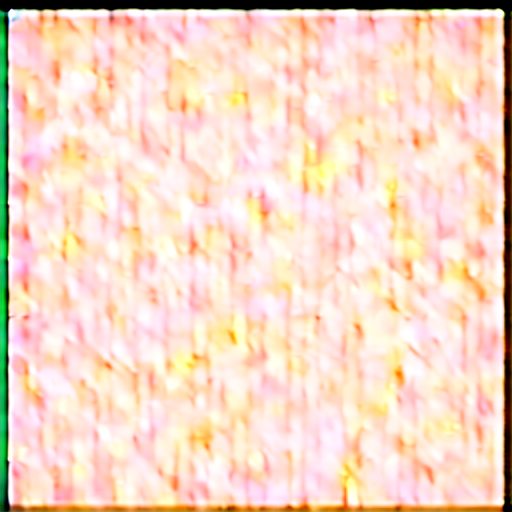

In [9]:
pipe.unet.eval()

image = pipe(
    "a handwritten digit five",
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

image
